### HYPOTHESE

Les communes avec une forte proportion de résidences secondaires
pourraient être plus exposées à certains risques naturels.

### OBJECTIF

Déterminer si les communes ayant une forte proportion de résidences secondaires
sont plus fréquemment touchées par des catastrophes naturelles.


In [1]:
# Import des bibliothèques

import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import geopandas as gpd

sns.set_style("whitegrid")


In [2]:
# Connexion à la base officielle DuckDB en lecture seule
con = duckdb.connect("dev.duckdb", read_only=True)

# Chargement des tables directement depuis la base
res2 = con.execute("SELECT * FROM res2_insee").df()
catnat = con.execute("SELECT * FROM catnat_gaspar").df()

# Vérification rapide
print("RES2 :", res2.shape)
print("CATNAT :", catnat.shape)


RES2 : (278947, 4)
CATNAT : (260799, 10)


In [3]:
# Aperçu du dataset Res2
res2.head()

,codgeo,libgeo,an,part_resid2
0,01001,L'Abergement-Clémenciat,1968,10.6
1,01001,L'Abergement-Clémenciat,1975,14.9
2,01001,L'Abergement-Clémenciat,1982,12.5
3,01001,L'Abergement-Clémenciat,1990,13.0
4,01001,L'Abergement-Clémenciat,1999,11.1


In [4]:
# Aperçu du Dataset Catnat
catnat.head()

,cod_nat_catnat,cod_commune,lib_commune,num_risque_jo,lib_risque_jo,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
0,BUDD8750027A,06120,Saint-Étienne-de-Tinée,GLT,Glissement de Terrain,1985-01-01,1986-12-31,1987-05-20,1987-05-24,2022-05-20 15:53:47.090
1,BUDD8750038A,2B050,Calvi,ICB,Inondations et/ou Coulées de Boue,1987-01-14,1987-01-15,1987-06-24,1987-07-10,2022-05-20 15:53:47.111
2,BUDD8750038A,30006,Aimargues,ICB,Inondations et/ou Coulées de Boue,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138
3,BUDD8750038A,30020,Aubord,ICB,Inondations et/ou Coulées de Boue,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138
4,BUDD8750038A,30033,Beauvoisin,ICB,Inondations et/ou Coulées de Boue,1987-02-11,1987-02-13,1987-06-24,1987-07-10,2022-05-20 15:53:47.138


In [5]:
# Forçage du type codgeo/ cod_commune  (Clé primaires)
res2["codgeo"] = res2["codgeo"].astype(str)
catnat["cod_commune"] = catnat["cod_commune"].astype(str)

# Vérification
print(res2.dtypes)
print(catnat.dtypes)


codgeo          object
libgeo          object
an               Int64
part_resid2    float64
dtype: object
cod_nat_catnat            object
cod_commune               object
lib_commune               object
num_risque_jo             object
lib_risque_jo             object
dat_deb           datetime64[us]
dat_fin           datetime64[us]
dat_pub_arrete    datetime64[us]
dat_pub_jo        datetime64[us]
dat_maj           datetime64[us]
dtype: object


In [6]:
# Verif cohérence longueur clés primaires
print("RES2")
print(res2["codgeo"].str.len().value_counts())

print("\nCATNAT")
print(catnat["cod_commune"].str.len().value_counts())


RES2
codgeo
5    278943
4         4
Name: count, dtype: int64

CATNAT
cod_commune
5    260799
Name: count, dtype: int64


In [7]:
# Vérification des 4 anomalies dans Res2
print(res2[res2["codgeo"].astype(str).str.len() == 4])

       codgeo libgeo    an  part_resid2
278943   None   None  <NA>          NaN
278944   None   None  <NA>          NaN
278945   None   None  <NA>          NaN
278946   None   None  <NA>          NaN


In [8]:
# Suppression de ces anomalies
res2 = res2[res2["codgeo"].astype(str).str.len() == 5].copy()

# Préparation des Datasets


In [9]:
# Années dispo dans Res2
sorted(res2["an"].unique())


[np.int64(1968),
 np.int64(1975),
 np.int64(1982),
 np.int64(1990),
 np.int64(1999),
 np.int64(2011),
 np.int64(2016),
 np.int64(2022)]

In [10]:
# Nombre de communes représentées par année
res2["an"].value_counts().sort_index()


an
1968    34867
1975    34867
1982    34867
1990    34867
1999    34850
2011    34875
2016    34875
2022    34875
Name: count, dtype: Int64

#### >> On observe que seules les années 1968 / 1975/ 1982/ 1990/ 1999/ 2011/ 2016/ 2022 sont représentées dans Res2


In [11]:
# Extraction de l'année de "Début" dan Catnat
catnat["dat_deb"] = pd.to_datetime(catnat["dat_deb"], errors="coerce")
catnat["an"] = catnat["dat_deb"].dt.year

# vérification des éventuelles anomalies
catnat["an"].isna().sum()


np.int64(0)

In [12]:
# Vérification de la période couverte par le dataset catnat
print("Première année :", catnat["an"].min())
print("Dernière année :", catnat["an"].max())


Première année : 1982
Dernière année : 2025


In [13]:
# Restreindre l'analyse aux périodes communes couvertes par CatNat et Res2 (>=1982)
res2 = res2[res2["an"] >= 1982].copy()
catnat = catnat[catnat["an"] >= 1982].copy()


In [14]:
# Synchronisation finale des années entre les deux datasets
common_years = sorted(set(res2["an"]).intersection(catnat["an"]))

res2 = res2[res2["an"].isin(common_years)].copy()
catnat = catnat[catnat["an"].isin(common_years)].copy()

print("Années analysées :", common_years)


Années analysées : [1982, 1990, 1999, 2011, 2016, 2022]


In [15]:
# Agrégation :  nombre de catastrophes par commune et par année
catnat_year = catnat.groupby(["cod_commune", "an"]).size().reset_index(name="nb_catnat")

catnat_year.head()


,cod_commune,an,nb_catnat
0,01002,1990,1
1,01004,1990,1
2,01004,2022,1
3,01005,1982,1
4,01006,1990,1


## Fusion des Datasets


In [16]:
# Fusion des données : conserver toutes les communes-années présentes dans RES2
analysis = res2.merge(
    catnat_year, left_on=["codgeo", "an"], right_on=["cod_commune", "an"], how="left"
)

# Remplacer absence de catastrophe par 0
analysis["nb_catnat"] = analysis["nb_catnat"].fillna(0).astype(int)

# Créer variable binaire : commune touchée au moins une fois cette année
analysis["touched"] = (analysis["nb_catnat"] > 0).astype(int)

# Supprimer colonne doublon issue du merge
analysis = analysis.drop(columns=["cod_commune"])

# Vérification rapide
print("RES2 :", len(res2))
print("ANALYSIS :", len(analysis))
analysis.head()


RES2 : 209209
ANALYSIS : 209209


,codgeo,libgeo,an,part_resid2,nb_catnat,touched
0,01001,L'Abergement-Clémenciat,1982,12.5,0,0
1,01001,L'Abergement-Clémenciat,1990,13.0,0,0
2,01001,L'Abergement-Clémenciat,1999,11.1,0,0
3,01001,L'Abergement-Clémenciat,2011,6.2,0,0
4,01001,L'Abergement-Clémenciat,2016,4.6,0,0


## Analyse


In [17]:
# Nombre total de catnat par commune (toutes années confondues)
catnat_total = analysis.groupby("codgeo")["nb_catnat"].sum()

In [18]:
# Classement jamais touchée/ touchée une fois/ touchée plusieurs fois
categories = pd.cut(
    catnat_total,
    bins=[-0.1, 0.1, 1.1, float("inf")],
    labels=["Jamais touchée", "Touchée une fois", "Touchée plusieurs fois"],
)

result = categories.value_counts().sort_index()

print(result)
print((result / result.sum() * 100).round(1))

nb_catnat
Jamais touchée              992
Touchée une fois            729
Touchée plusieurs fois    33154
Name: count, dtype: int64
nb_catnat
Jamais touchée             2.8
Touchée une fois           2.1
Touchée plusieurs fois    95.1
Name: count, dtype: float64


In [19]:
# Nb catnat par année
catnat_per_year = analysis.groupby("an")["nb_catnat"].sum()

print(catnat_per_year)

an
1982    33886
1990     3387
1999    57920
2011     3425
2016     4178
2022     8770
Name: nb_catnat, dtype: int64


In [20]:
# Taux de communes touchées par les catnat par année
touched_rate = analysis.groupby("an")["touched"].mean()

print(touched_rate.round(2))

an
1982    0.48
1990    0.08
1999    0.80
2011    0.09
2016    0.11
2022    0.21
Name: touched, dtype: float64


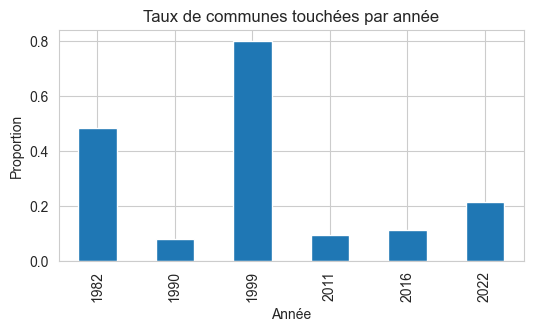

In [21]:
touched_rate.plot(kind="bar", figsize=(6, 3))
plt.title("Taux de communes touchées par année")
plt.ylabel("Proportion")
plt.xlabel("Année")
plt.show()

In [22]:
# Taux moyen de résidences secondaires parmi les communes touchées
resid2_touched = analysis[analysis["touched"] == 1].groupby("an")["part_resid2"].mean()

print(resid2_touched)

an
1982    17.796797
1990    15.006900
1999    13.248108
2011    13.558851
2016     9.616189
2022    10.320973
Name: part_resid2, dtype: float64


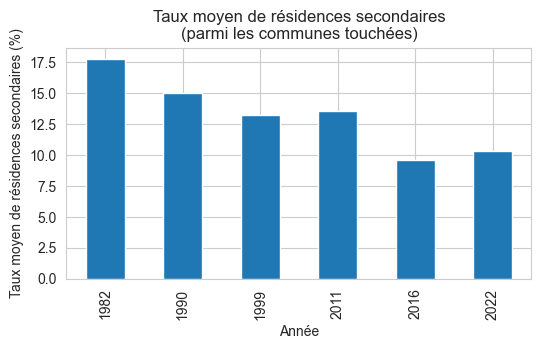

In [23]:
resid2_touched.plot(kind="bar", figsize=(6, 3))

plt.title("Taux moyen de résidences secondaires\n(parmi les communes touchées)")
plt.xlabel("Année")
plt.ylabel("Taux moyen de résidences secondaires (%)")
plt.show()

In [24]:
# Comparaison du taux moyen de résidences secondaires dans les communes touchées vs. non touchées
mean_comp = analysis.groupby(["an", "touched"])["part_resid2"].mean().unstack()

print(mean_comp)

touched          0          1
an                           
1982     15.147573  17.796797
1990     16.756476  15.006900
1999     24.878593  13.248108
2011     13.764856  13.558851
2016     13.772373   9.616189
2022     13.812939  10.320973


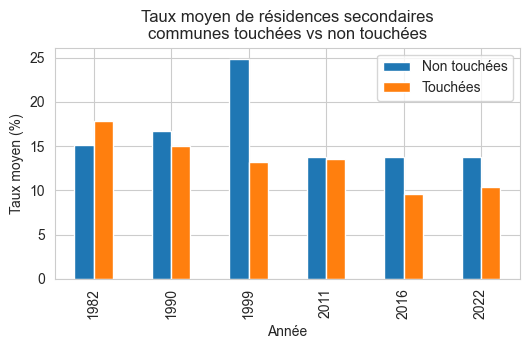

In [25]:
mean_comp.plot(kind="bar", figsize=(6, 3))

plt.title("Taux moyen de résidences secondaires\ncommunes touchées vs non touchées")
plt.ylabel("Taux moyen (%)")
plt.xlabel("Année")
plt.legend(["Non touchées", "Touchées"])
plt.show()

In [26]:
# Ecart des moyennes
mean_comp["écart_touchées_vs_non"] = mean_comp[1] - mean_comp[0]
mean_comp

touched,0,1,écart_touchées_vs_non
an,,,
1982,15.147573,17.796797,2.649223
1990,16.756476,15.006900,-1.749576
1999,24.878593,13.248108,-11.630485
2011,13.764856,13.558851,-0.206005
2016,13.772373,9.616189,-4.156184
2022,13.812939,10.320973,-3.491966


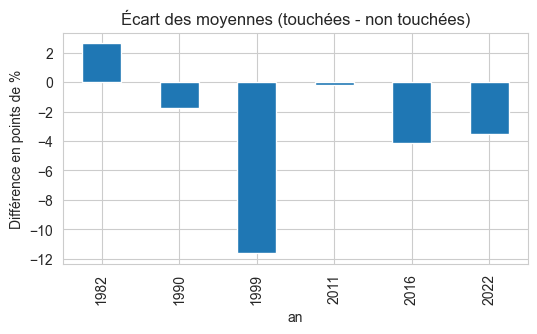

In [27]:
mean_comp["écart_touchées_vs_non"].plot(kind="bar", figsize=(6, 3))
plt.title("Écart des moyennes (touchées - non touchées)")
plt.ylabel("Différence en points de %")
plt.show()

In [28]:
# Comparaison de la médiane de résidences secondaires dans les communes touchées vs. non touchées
median_comp = analysis.groupby(["an", "touched"])["part_resid2"].median().unstack()

print(median_comp)

touched     0     1
an                 
1982     11.3  13.9
1990     12.5   9.2
1999     19.2   9.4
2011      8.3   8.0
2016      8.0   5.0
2022      7.7   5.5


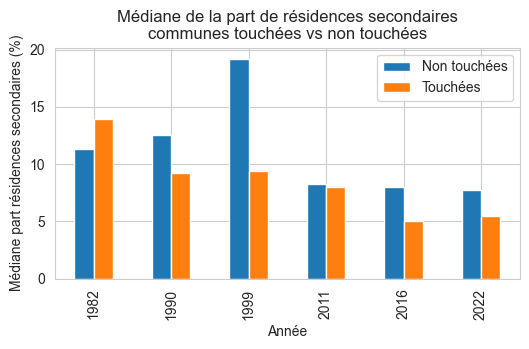

In [29]:
median_comp.plot(kind="bar", figsize=(6, 3))

plt.title(
    "Médiane de la part de résidences secondaires\ncommunes touchées vs non touchées"
)
plt.xlabel("Année")
plt.ylabel("Médiane part résidences secondaires (%)")
plt.legend(["Non touchées", "Touchées"])
plt.show()

In [30]:
# Ecart des médianes
median_comp["écart_touchées_vs_non"] = median_comp[1] - median_comp[0]
median_comp

touched,0,1,écart_touchées_vs_non
an,,,
1982,11.3,13.9,2.6
1990,12.5,9.2,-3.3
1999,19.2,9.4,-9.8
2011,8.3,8.0,-0.3
2016,8.0,5.0,-3.0
2022,7.7,5.5,-2.2


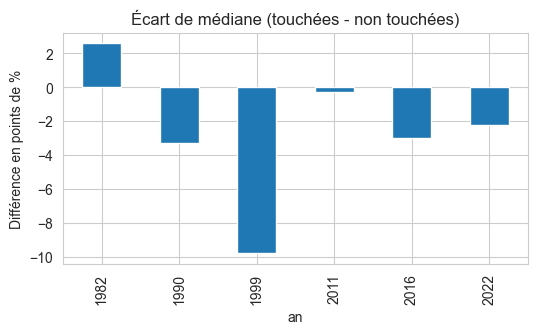

In [31]:
median_comp["écart_touchées_vs_non"].plot(kind="bar", figsize=(6, 3))
plt.title("Écart de médiane (touchées - non touchées)")
plt.ylabel("Différence en points de %")
plt.show()

### Analyse par niveau d'exposition catnat (quartile)

nous avons vu que la moyenne et la médiane globales ne montre rien de claire .. Les communes très exposées sont elles différentes ?


In [32]:
# Total catnat par commune
catnat_total = (
    analysis.groupby("codgeo")["nb_catnat"].sum().reset_index(name="total_catnat")
)
print(catnat_total)

      codgeo  total_catnat
0      01001             0
1      01002             1
2      01004             2
3      01005             1
4      01006             1
...      ...           ...
34870  97613             0
34871  97614             1
34872  97615             0
34873  97616             0
34874  97617             0

[34875 rows x 2 columns]


In [33]:
# Résidences secondaires moyennes par commune
res2_mean = analysis.groupby("codgeo")["part_resid2"].mean().reset_index()
print(res2_mean)

      codgeo  part_resid2
0      01001     8.383333
1      01002    39.133333
2      01004     2.683333
3      01005     3.116667
4      01006    20.800000
...      ...          ...
34870  97613          NaN
34871  97614          NaN
34872  97615          NaN
34873  97616          NaN
34874  97617          NaN

[34875 rows x 2 columns]


In [34]:
# base commune
extreme_base = res2_mean.merge(catnat_total, on="codgeo")
print(extreme_base)

      codgeo  part_resid2  total_catnat
0      01001     8.383333             0
1      01002    39.133333             1
2      01004     2.683333             2
3      01005     3.116667             1
4      01006    20.800000             1
...      ...          ...           ...
34870  97613          NaN             0
34871  97614          NaN             1
34872  97615          NaN             0
34873  97616          NaN             0
34874  97617          NaN             0

[34875 rows x 3 columns]


In [35]:
# Groupe d'exposition / quartile
extreme_base["groupe_exposition"] = pd.qcut(
    extreme_base["total_catnat"],
    q=4,
    labels=["Faible", "Moyenne-faible", "Moyenne-forte", "Forte"],
)

In [36]:
extreme_base.groupby("groupe_exposition")["part_resid2"].agg(
    ["count", "mean", "median", "std"]
)

C:\Users\Nella\AppData\Local\Temp\ipykernel_8472\789975394.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  extreme_base.groupby("groupe_exposition")["part_resid2"].agg(


,count,mean,median,std
groupe_exposition,,,,
Faible,14009,16.197492,10.933333,15.876170
Moyenne-faible,8481,12.916193,9.133333,12.881692
Moyenne-forte,6661,16.887197,12.566667,14.828723
Forte,5703,11.679563,8.116667,11.416992


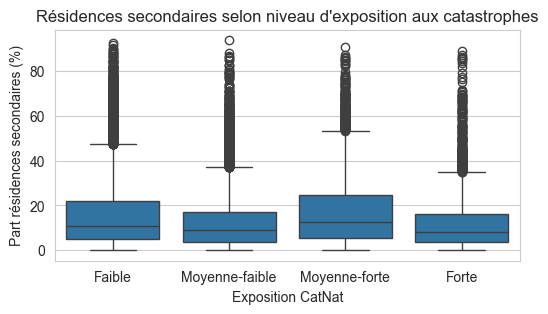

In [37]:
plt.figure(figsize=(6, 3))
sns.boxplot(data=extreme_base, x="groupe_exposition", y="part_resid2")

plt.title("Résidences secondaires selon niveau d'exposition aux catastrophes")
plt.xlabel("Exposition CatNat")
plt.ylabel("Part résidences secondaires (%)")
plt.show()

In [38]:
# Base commune : total CatNat + stats résidences secondaires + nom commune
commune_base = analysis.groupby(["codgeo", "libgeo"], as_index=False).agg(
    total_catnat=("nb_catnat", "sum"),
    mean_part_resid2=("part_resid2", "mean"),
    median_part_resid2=("part_resid2", "median"),
)

commune_base.head()

,codgeo,libgeo,total_catnat,mean_part_resid2,median_part_resid2
0,01001,L'Abergement-Clémenciat,0,8.383333,8.65
1,01002,L'Abergement-de-Varey,1,39.133333,38.30
2,01004,Ambérieu-en-Bugey,2,2.683333,2.15
3,01005,Ambérieux-en-Dombes,1,3.116667,2.25
4,01006,Ambléon,1,20.800000,20.55


### Vérification géographique


In [39]:
# création des codes département
def extract_departement(code):
    code = str(code)
    if code.startswith("97") or code.startswith("98"):
        return code[:3]  # DOM
    elif code.startswith("2A") or code.startswith("2B"):
        return code[:2]  # Corse
    else:
        return code[:2]  # Métropole


analysis["departement"] = analysis["codgeo"].apply(extract_departement)

analysis["departement"].value_counts().head()

departement
62    5322
02    4782
80    4626
57    4350
76    4242
Name: count, dtype: int64

In [40]:
# Corrélation par département
corr_dep = (
    analysis.groupby("departement")
    .apply(lambda x: x["part_resid2"].corr(x["nb_catnat"]))
    .dropna()
)

corr_dep.sort_values()

C:\Users\Nella\AppData\Local\Temp\ipykernel_8472\3177847454.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["part_resid2"].corr(x["nb_catnat"]))


departement
83   -0.220031
75   -0.200976
04   -0.198751
11   -0.185264
12   -0.145238
        ...   
85    0.101649
93    0.106146
74    0.127711
42    0.175953
69    0.181330
Length: 100, dtype: float64

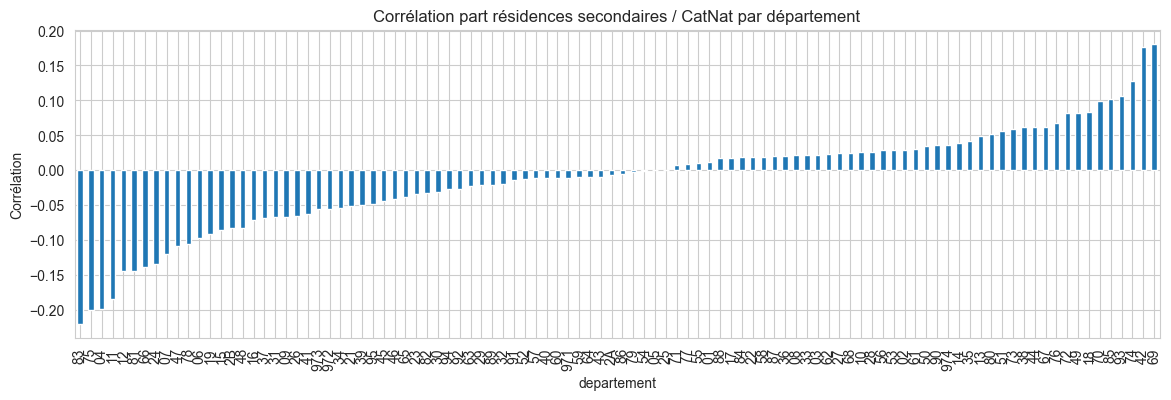

In [41]:
corr_dep.sort_values().plot(kind="bar", figsize=(14, 4))
plt.title("Corrélation part résidences secondaires / CatNat par département")
plt.ylabel("Corrélation")
plt.show()

#### Illustration avec les extrêmes Top10


In [42]:
# Top 10 des communes les plus touchées par les catnat vs. mean/ median des résidences secondaires
top10_catnat = commune_base.sort_values("total_catnat", ascending=False).head(10)
top10_catnat

,codgeo,libgeo,total_catnat,mean_part_resid2,median_part_resid2
28274,71574,Verzé,21,8.766667,7.80
11770,31555,Toulouse,17,3.033333,3.00
7882,24026,Bassillac et Auberoche,16,10.733333,10.55
27742,71016,Azé,14,10.916667,9.95
24562,63227,Mirefleurs,14,4.416667,2.35
27454,70285,Héricourt,13,1.300000,1.20
29753,76595,Saint-Jouin-Bruneval,13,10.816667,9.80
29515,76349,Hautot-sur-Mer,13,12.033333,10.50
29368,76192,Criel-sur-Mer,12,45.266667,43.70
29427,76254,Étretat,12,39.866667,37.00


In [43]:
# top 10 des communes avec le plus de résidences secondaires vs. le nombre de catnat
top10_resid2 = commune_base.sort_values("mean_part_resid2", ascending=False).head(10)
top10_resid2

,codgeo,libgeo,total_catnat,mean_part_resid2,median_part_resid2
28905,73318,Villarembert,3,93.816667,93.85
1798,05110,Puy-Saint-Vincent,0,92.533333,93.60
1687,04226,Uvernet-Fours,0,91.766667,92.20
21262,57579,Rhodes,4,90.800000,90.95
1787,05098,Les Orres,0,90.200000,90.90
25822,66004,Les Angles,2,89.816667,90.05
1807,05119,Risoul,0,89.616667,90.70
25001,64204,Eaux-Bonnes,6,89.216667,89.20
1857,05177,Vars,0,88.883333,89.30
1508,04006,Allos,0,88.583333,91.50


#### Analyse selon le type de CatNat


In [44]:
# Vérification rapide des colonnes disponibles
catnat.columns

Index(['cod_nat_catnat', 'cod_commune', 'lib_commune', 'num_risque_jo',
       'lib_risque_jo', 'dat_deb', 'dat_fin', 'dat_pub_arrete', 'dat_pub_jo',
       'dat_maj', 'an'],
      dtype='object')

In [45]:
# Table CatNat agrégée : nombre d'événements par commune / année / type de risque
catnat_risk_year = (
    catnat.groupby(["cod_commune", "an", "lib_risque_jo"], as_index=False)
    .size()
    .rename(columns={"size": "nb_catnat"})
)

catnat_risk_year.head()

,cod_commune,an,lib_risque_jo,nb_catnat
0,01002,1990,Inondations et/ou Coulées de Boue,1
1,01004,1990,Inondations et/ou Coulées de Boue,1
2,01004,2022,Sécheresse,1
3,01005,1982,Inondations et/ou Coulées de Boue,1
4,01006,1990,Inondations et/ou Coulées de Boue,1


In [46]:
# Refonte du dataset avec ajout des types de CatNat

analysis_risk = res2.merge(
    catnat_risk_year,
    left_on=["codgeo", "an"],
    right_on=["cod_commune", "an"],
    how="left",
)

# 0 CatNat quand aucune ligne CatNat pour la commune/année
analysis_risk["nb_catnat"] = analysis_risk["nb_catnat"].fillna(0)

# Si pas d'événement, il n'y a pas de risque associé → on met "Aucun"
analysis_risk["lib_risque_jo"] = analysis_risk["lib_risque_jo"].fillna("Aucun")

analysis_risk.head()

,codgeo,libgeo,an,part_resid2,cod_commune,lib_risque_jo,nb_catnat
0,01001,L'Abergement-Clémenciat,1982,12.5,NaN,Aucun,0.0
1,01001,L'Abergement-Clémenciat,1990,13.0,NaN,Aucun,0.0
2,01001,L'Abergement-Clémenciat,1999,11.1,NaN,Aucun,0.0
3,01001,L'Abergement-Clémenciat,2011,6.2,NaN,Aucun,0.0
4,01001,L'Abergement-Clémenciat,2016,4.6,NaN,Aucun,0.0


In [47]:
# Nombre catnat par type
analysis_risk["lib_risque_jo"].value_counts().head(10)

lib_risque_jo
Aucun                                          147239
Inondations et/ou Coulées de Boue               50883
Mouvement de Terrain                            26419
Tempête                                         12074
Sécheresse                                      10675
Chocs Mécaniques liés à l'action des Vagues      2782
Poids de la Neige                                1403
Glissement de Terrain                              64
Avalanche                                          27
Inondations Remontée Nappe                         26
Name: count, dtype: int64

In [48]:
# Médiane/ Moyenne de résidences secondaires selon le type de CatNat

risk_resid = (
    analysis_risk[analysis_risk["lib_risque_jo"] != "Aucun"]
    .groupby("lib_risque_jo")
    .agg(
        median_resid2=("part_resid2", "median"),
        mean_resid2=("part_resid2", "mean"),
        nb_communes=("codgeo", "nunique"),  # nb de communes distinctes touchées
        total_evenements=("nb_catnat", "sum"),  # nb total d'événements CatNat (somme)
    )
    .sort_values("median_resid2", ascending=False)
)

risk_resid.head(10)

,median_resid2,mean_resid2,nb_communes,total_evenements
lib_risque_jo,,,,
Avalanche,68.50,67.033333,25,31.0
Eboulement et/ou Chute de Blocs,54.85,54.850000,2,2.0
Poids de la Neige,17.40,19.829294,1403,1403.0
Tempête,16.70,20.382524,12074,12074.0
Raz de Marée,16.60,16.600000,1,1.0
Inondations et/ou Coulées de Boue,10.60,14.849351,33647,56649.0
Mouvement de Terrain,9.30,12.989343,26273,26460.0
Secousse Sismique,8.90,12.570588,17,17.0
Chocs Mécaniques liés à l'action des Vagues,8.20,12.913659,2756,2834.0


##### Les catastrophes de type avalanche et éboulement apparaissent associées à des communes présentant une forte proportion de résidences secondaires. Toutefois, ces résultats concernent un nombre très limité de communes et reflètent principalement des territoires de montagne à forte activité touristique


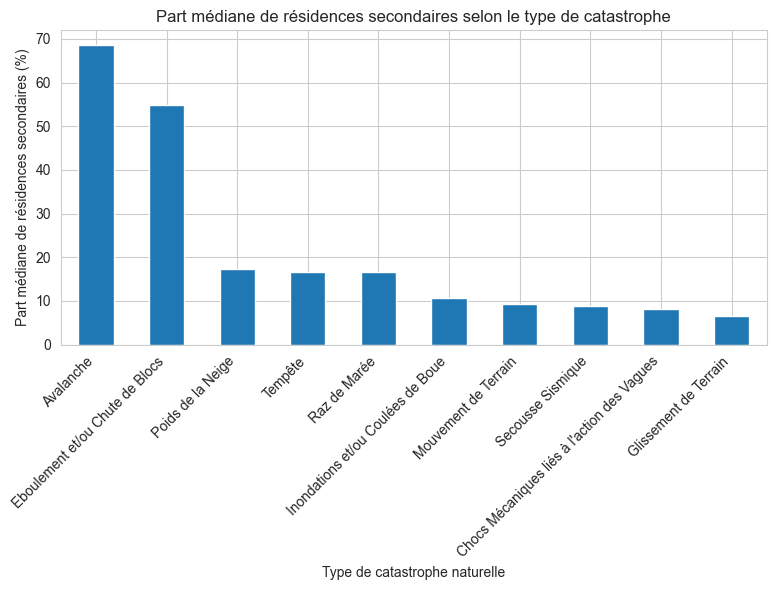

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

risk_resid["median_resid2"].head(10).plot(kind="bar")

plt.ylabel("Part médiane de résidences secondaires (%)")
plt.xlabel("Type de catastrophe naturelle")
plt.title("Part médiane de résidences secondaires selon le type de catastrophe")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

##### On observe que les CatNat avec la part de résidences secondaires la plus importantes sont les avalanches et les Eboulements/ Chute de blocs.


In [50]:
map_data = analysis.groupby(["codgeo", "libgeo"], as_index=False).agg(
    total_catnat=("nb_catnat", "sum"),
    mean_resid2=("part_resid2", "mean"),
)

map_data.head()

,codgeo,libgeo,total_catnat,mean_resid2
0,01001,L'Abergement-Clémenciat,0,8.383333
1,01002,L'Abergement-de-Varey,1,39.133333
2,01004,Ambérieu-en-Bugey,2,2.683333
3,01005,Ambérieux-en-Dombes,1,3.116667
4,01006,Ambléon,1,20.800000


In [51]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


## Cartographie


In [52]:
# Charger le fond communal depuis Opendatasoft
communes = gpd.read_file(
    "https://public.opendatasoft.com/api/explore/v2.1/catalog/datasets/georef-france-commune/exports/geojson"
)

print(communes.columns)

Index(['geo_point_2d', 'year', 'reg_code', 'reg_name', 'dep_code', 'dep_name',
       'arrdep_code', 'arrdep_name', 'ze2020_code', 'ze2020_name',
       'bv2022_code', 'bv2022_name', 'epci_code', 'epci_name', 'ept_code',
       'ept_name', 'com_code', 'com_current_code', 'com_name',
       'com_name_upper', 'com_name_lower', 'com_area_code', 'com_type',
       'ze2010_name', 'ze2010_code', 'com_cataeu2010_code',
       'com_cataeu2010_name', 'com_uu2010_code', 'com_uu2010_status',
       'com_au2010_code', 'com_cateaav2020_code', 'com_cateaav2020_name',
       'com_uu2020_code', 'com_uu2020_status', 'com_aav2020_code',
       'com_cv_code', 'com_in_ctu', 'com_siren_code', 'com_is_mountain_area',
       'geometry'],
      dtype='object')


In [53]:
# Garder uniquement les colonnes utiles
communes = communes[["com_code", "com_name", "geometry"]].copy()

# Renommer les colonnes pour harmoniser avec le reste du notebook
communes = communes.rename(
    columns={"com_code": "code_commune", "com_name": "nom_commune"}
)

# Nettoyer et harmonisation les valeurs textuelles
communes["code_commune"] = (
    communes["code_commune"]
    .astype(str)
    .str.strip()
    .str.replace(r"^\['?", "", regex=True)
    .str.replace(r"'?\]$", "", regex=True)
    .str.replace(".0", "", regex=False)
    .str.zfill(5)
)

communes["nom_commune"] = (
    communes["nom_commune"]
    .astype(str)
    .str.strip()
    .str.replace(r"^\['?", "", regex=True)
    .str.replace(r"'?\]$", "", regex=True)
)

communes = communes[~communes["code_commune"].str.startswith(("97", "98"))].copy()

# 6) Vérification rapide
communes[["code_commune", "nom_commune"]].head()

,code_commune,nom_commune
0,23048,Champagnat
1,23080,Féniers
2,15112,Malbo
3,59358,Looberghe
4,59399,Merris


In [54]:
# Agréger les données d'analyse au niveau commune
map_data = analysis.groupby(["codgeo", "libgeo"], as_index=False).agg(
    total_catnat=("nb_catnat", "sum"),
    mean_resid2=("part_resid2", "mean"),
)

# Harmoniser le code commune côté données d'analyse
map_data["codgeo"] = (
    map_data["codgeo"]
    .astype(str)
    .str.strip()
    .str.replace(".0", "", regex=False)
    .str.zfill(5)
)

map_data = map_data[~map_data["codgeo"].str.startswith(("97", "98"))].copy()

map_data.head()

,codgeo,libgeo,total_catnat,mean_resid2
0,01001,L'Abergement-Clémenciat,0,8.383333
1,01002,L'Abergement-de-Varey,1,39.133333
2,01004,Ambérieu-en-Bugey,2,2.683333
3,01005,Ambérieux-en-Dombes,1,3.116667
4,01006,Ambléon,1,20.800000


In [55]:
# Fusionner le fond de carte avec les indicateurs
map_df = communes.merge(map_data, left_on="code_commune", right_on="codgeo", how="left")

map_df.head()

,code_commune,nom_commune,geometry,codgeo,libgeo,total_catnat,mean_resid2
0,23048,Champagnat,"POLYGON ((2.27793 45.99085, 2.27791 45.99156, ...",23048,Champagnat,4,36.683333
1,23080,Féniers,"POLYGON ((2.15657 45.72163, 2.15798 45.72354, ...",23080,Féniers,4,40.150000
2,15112,Malbo,"POLYGON ((2.7384 44.94144, 2.73916 44.94197, 2...",15112,Malbo,4,34.050000
3,59358,Looberghe,"POLYGON ((2.3139 50.9027, 2.31232 50.90355, 2....",59358,Looberghe,4,3.616667
4,59399,Merris,"POLYGON ((2.67674 50.69892, 2.67652 50.6994, 2...",59399,Merris,7,1.450000


In [56]:
print("Nombre de communes dans la carte :", len(map_df))
print("Communes avec données :", map_df["total_catnat"].notna().sum())

Nombre de communes dans la carte : 34746
Communes avec données : 34746


In [57]:
# Identifier les communes sans cas CatNat
map_df["no_case"] = map_df["total_catnat"].isna() | (map_df["total_catnat"] == 0)

# Remplir les valeurs manquantes pour les traitements statistiques
map_df["total_catnat_filled"] = map_df["total_catnat"].fillna(0)
map_df["mean_resid2_filled"] = map_df["mean_resid2"].fillna(0)

In [58]:
# Classer les communes avec au moins un cas en 3 groupes : faible / moyen / fort, pour CatNat et résidences secondaires
mask_cases = ~map_df["no_case"]

map_df.loc[mask_cases, "catnat_class"] = pd.qcut(
    map_df.loc[mask_cases, "total_catnat_filled"],
    3,
    labels=["Faible", "Moyen", "Fort"],
    duplicates="drop",
)

map_df.loc[mask_cases, "resid_class"] = pd.qcut(
    map_df.loc[mask_cases, "mean_resid2_filled"],
    3,
    labels=["Faible", "Moyen", "Fort"],
    duplicates="drop",
)

In [59]:
# Définir les couleurs de la carte bivariée
bivariate_colors = {
    "Faible-Faible": "#e8e8e8",
    "Faible-Moyen": "#b5c0da",
    "Faible-Fort": "#6c83b5",
    "Moyen-Faible": "#b8d6be",
    "Moyen-Moyen": "#90b2b3",
    "Moyen-Fort": "#567994",
    "Fort-Faible": "#73ae80",
    "Fort-Moyen": "#5a9178",
    "Fort-Fort": "#2a5a5b",
}

# Construire la combinaison des deux classes
map_df["bivariate"] = (
    map_df["catnat_class"].astype(str) + "-" + map_df["resid_class"].astype(str)
)

# Associer chaque combinaison à une couleur
map_df["color"] = map_df["bivariate"].map(bivariate_colors)

# Gris pour les communes sans cas
map_df.loc[map_df["no_case"], "color"] = "#d9d9d9"
map_df["color"] = map_df["color"].fillna("#d9d9d9")

In [60]:
# Créer une légende bivariée simple
def add_bivariate_legend(ax, colors, x=0.04, y=0.05, size=0.03, pad=0.003):
    grid = [
        ["Faible-Faible", "Faible-Moyen", "Faible-Fort"],
        ["Moyen-Faible", "Moyen-Moyen", "Moyen-Fort"],
        ["Fort-Faible", "Fort-Moyen", "Fort-Fort"],
    ]

    for i in range(3):
        for j in range(3):
            key = grid[i][j]
            rect = Rectangle(
                (x + j * (size + pad), y + i * (size + pad)),
                size,
                size,
                facecolor=colors[key],
                edgecolor="white",
                transform=ax.transAxes,
            )
            ax.add_patch(rect)

    ax.text(
        x, y + 3 * (size + pad) + 0.01, "CatNat ↑", transform=ax.transAxes, fontsize=9
    )
    ax.text(
        x + 3 * (size + pad) + 0.01,
        y,
        "Résidences secondaires →",
        transform=ax.transAxes,
        fontsize=9,
    )

    ax.text(x, y - 0.015, "Faible", transform=ax.transAxes, fontsize=8)
    ax.text(x + size + pad, y - 0.015, "Moyen", transform=ax.transAxes, fontsize=8)
    ax.text(x + 2 * (size + pad), y - 0.015, "Fort", transform=ax.transAxes, fontsize=8)

    ax.text(x - 0.015, y, "Faible", transform=ax.transAxes, fontsize=8, rotation=90)
    ax.text(
        x - 0.015,
        y + size + pad,
        "Moyen",
        transform=ax.transAxes,
        fontsize=8,
        rotation=90,
    )
    ax.text(
        x - 0.015,
        y + 2 * (size + pad),
        "Fort",
        transform=ax.transAxes,
        fontsize=8,
        rotation=90,
    )

    rect = Rectangle(
        (x, y - 0.08),
        size,
        size,
        facecolor="#d9d9d9",
        edgecolor="white",
        transform=ax.transAxes,
    )
    ax.add_patch(rect)

    ax.text(
        x + size + 0.01, y - 0.075, "Pas de cas", transform=ax.transAxes, fontsize=8
    )

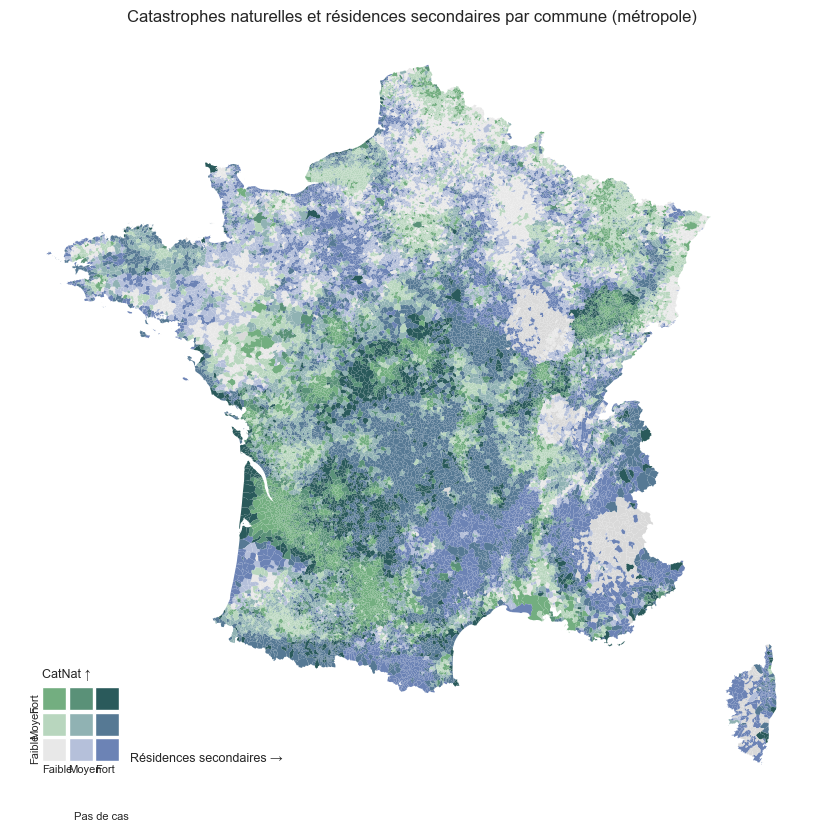

In [61]:
# Afficher la carte
fig, ax = plt.subplots(figsize=(11, 10))

map_df.plot(color=map_df["color"], linewidth=0, ax=ax)

ax.set_title(
    "Catastrophes naturelles et résidences secondaires par commune (métropole)"
)
ax.axis("off")

add_bivariate_legend(ax, bivariate_colors)

plt.show()

### SYNTHESE DES RESULTATS

Plusieurs indicateurs ont été vérifiés : moyennes, médianes et segmentation par quartiles d’exposition, afin d’évaluer à la fois les niveaux globaux et les distributions selon l’intensité d’exposition.

les écarts observés entre communes touchées et non touchées sont faibles et non systématiques. L’analyse par quartiles ne montre pas non plus de corrélation entre niveau d’exposition (faible, moyen, fort) et part de résidences secondaires.

L’approche départementale confirme cette absence : corrélations faibles et réparties de manière symétrique autour de zéro.

L’examen du top 10 des communes extrêmes renforce ce constat : les communes les plus exposées ne présentent pas nécessairement une forte proportion de résidences secondaires, tandis que plusieurs communes très touristiques apparaissent peu ou pas touchées.

Enfin, l’analyse par type de catastrophe naturelle montre que certains risques, notamment les avalanches ou les éboulements, concernent des communes présentant une forte proportion de résidences secondaires, mais ces résultats reposent sur un nombre très limité de territoires et reflètent principalement des zones touristiques de montagne.
La cartographie bivariée confirme visuellement ces observations : les zones fortement exposées aux catastrophes naturelles ne correspondent pas systématiquement aux territoires où la part de résidences secondaires est la plus élevée.

En conséquence, l’hypothèse d’un lien direct entre résidences secondaires et exposition aux catastrophes naturelles n’est pas confirmée par les données disponibles sur la période étudiée (années communes aux deux jeux de données : 1982, 1990, 1999, 2011, 2016 et 2022).
